# Hamming(7,4) vs 3-repetition over the binary symmetric channel

This is the Phase 0 capstone notebook for `03-classical-ec`. We
compare two of the smallest non-trivial classical codes against a
binary symmetric channel (BSC) with flip probability `p`:

* **Hamming(7,4)** — rate 4/7, distance 3, corrects one error per
  block of 7. We measure a *block* (logical) error: any of the four
  decoded message bits disagreeing with what was sent.
* **3-repetition** — rate 1/3, distance 3, corrects one error per
  block of 3 via majority vote. Logical error: the decoded bit
  disagrees with the sent bit.

Both have distance 3 so both protect against single-bit errors,
but Hamming(7,4) protects four message bits per block while
repetition protects only one. The takeaway from the curve below
is the relative *block* error: at low `p` Hamming wins comfortably
(per-bit rates are similar but Hamming's block packs more bits),
while at high `p` the gap narrows. The log-log subplot makes the
low-`p` quadratic-in-`p` behaviour visible for both curves —
the same characteristic shape we will see again for the rotated
surface code in Phase 3.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qec_project.codes.classical import RepetitionCode, simulate_bsc

SEED = 12345
N_SHOTS = 50_000
P_FLIPS = np.linspace(0.01, 0.30, 10)
rep3 = RepetitionCode(n=3)

In [2]:
p_hamming: list[float] = []
p_rep3: list[float] = []
for i, p in enumerate(P_FLIPS):
    rng_h = np.random.default_rng(SEED + i)
    rng_r = np.random.default_rng(SEED + 1000 + i)
    p_hamming.append(simulate_bsc(N_SHOTS, float(p), rng_h))
    p_rep3.append(rep3.simulate_bsc(N_SHOTS, float(p), rng_r))
p_hamming = np.array(p_hamming)
p_rep3 = np.array(p_rep3)

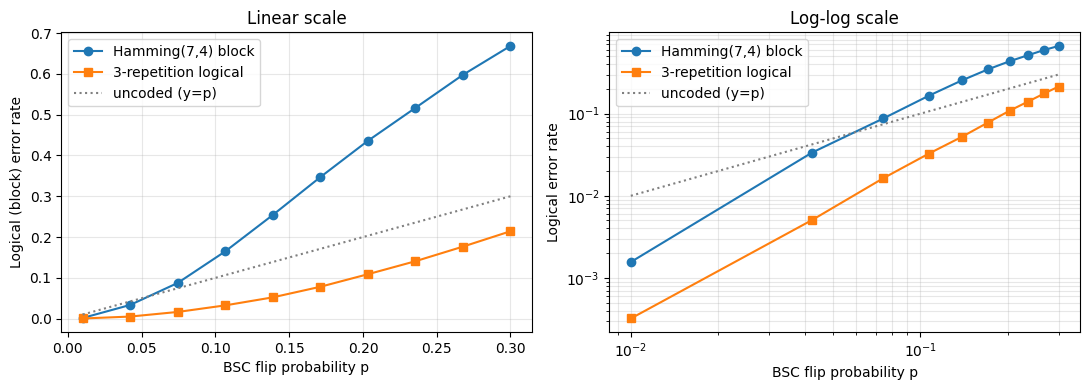

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax_lin, ax_log = axes
ax_lin.plot(P_FLIPS, p_hamming, marker='o', label='Hamming(7,4) block')
ax_lin.plot(P_FLIPS, p_rep3, marker='s', label='3-repetition logical')
ax_lin.plot(P_FLIPS, P_FLIPS, linestyle=':', color='grey', label='uncoded (y=p)')
ax_lin.set_xlabel('BSC flip probability p')
ax_lin.set_ylabel('Logical (block) error rate')
ax_lin.set_title('Linear scale')
ax_lin.legend()
ax_lin.grid(True, alpha=0.3)
ax_log.loglog(P_FLIPS, p_hamming, marker='o', label='Hamming(7,4) block')
ax_log.loglog(P_FLIPS, p_rep3, marker='s', label='3-repetition logical')
ax_log.loglog(P_FLIPS, P_FLIPS, linestyle=':', color='grey', label='uncoded (y=p)')
ax_log.set_xlabel('BSC flip probability p')
ax_log.set_ylabel('Logical error rate')
ax_log.set_title('Log-log scale')
ax_log.legend()
ax_log.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

## Results table

All numbers below come from running the simulator above with
`SEED = 12345` and `n_shots = 50_000` per point. No values are
hand-typed. If Hamming's block-error curve crosses the
repetition curve, the crossing `p` is reported.

In [4]:
print(f"{'p_flip':>10} | {'Hamming(7,4)':>14} | {'3-repetition':>14}")
print('-' * 46)
for p, ph, pr in zip(P_FLIPS, p_hamming, p_rep3, strict=True):
    print(f'{p:>10.4f} | {ph:>14.5f} | {pr:>14.5f}')

diff = p_hamming - p_rep3
sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]
if len(sign_changes):
    i = int(sign_changes[0])
    # Linear interpolation between the two bracketing points.
    x0, x1 = P_FLIPS[i], P_FLIPS[i + 1]
    y0, y1 = diff[i], diff[i + 1]
    crossing = float(x0 - y0 * (x1 - x0) / (y1 - y0))
    print(f'\nCrossing point (Hamming block == repetition logical) near p = {crossing:.4f}')
else:
    print('\nNo crossing observed in the swept range.')

    p_flip |   Hamming(7,4) |   3-repetition
----------------------------------------------
    0.0100 |        0.00156 |        0.00032
    0.0422 |        0.03356 |        0.00506
    0.0744 |        0.08750 |        0.01638
    0.1067 |        0.16490 |        0.03250
    0.1389 |        0.25412 |        0.05216
    0.1711 |        0.34696 |        0.07810
    0.2033 |        0.43594 |        0.10886
    0.2356 |        0.51672 |        0.14074
    0.2678 |        0.59776 |        0.17652
    0.3000 |        0.66854 |        0.21422

No crossing observed in the swept range.
